<h1> Link PDF</h1>

https://drive.google.com/drive/folders/1pk_Jv75huqrqqHod_gTd7jDTrkPX2nj4?hl=es

<h1> Proyecto Telecom</h1>

<h1> Preparacion Y Exploracion De Datos</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('/datasets/telecom_dataset_us.csv')
clients = pd.read_csv('/datasets/telecom_clients_us.csv')

print(df.shape)
print(df.info())
print(df.head())

print(clients.head())

df['date'] = pd.to_datetime(df['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

print(df.isnull().sum())

print(df.duplicated().sum())

print(df['direction'].unique())
print(df['internal'].unique())

(53902, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None
   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:0

<h1> Limpieza y Transformación de Datos </h1>

In [2]:
df = df.dropna(subset=['operator_id'])

df['operator_id'] = df['operator_id'].astype(int)

df['waiting_time'] = df['total_call_duration'] - df['call_duration']

df = df[df['waiting_time'] >= 0]

df.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration,waiting_time
count,45730.000000,45730.000000,45730.000000,45730.000000,45730.000000,45730.000000
mean,167302.220315,916535.993002,16.904417,1009.765121,1322.141789,312.376667
std,600.731240,21254.123136,59.045234,4014.600085,4732.427880,1174.185593
min,166377.000000,879896.000000,1.000000,0.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,68.000000,19.000000
50%,167175.000000,913938.000000,4.000000,106.000000,290.500000,60.000000
75%,167827.000000,937708.000000,14.000000,772.000000,1110.000000,220.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000,46474.000000


<h1> Análisis Exploratorio (EDA) </h1>

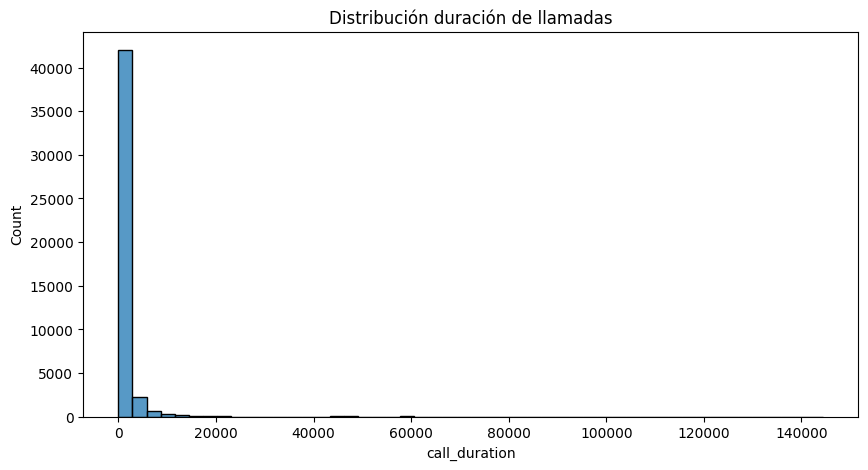

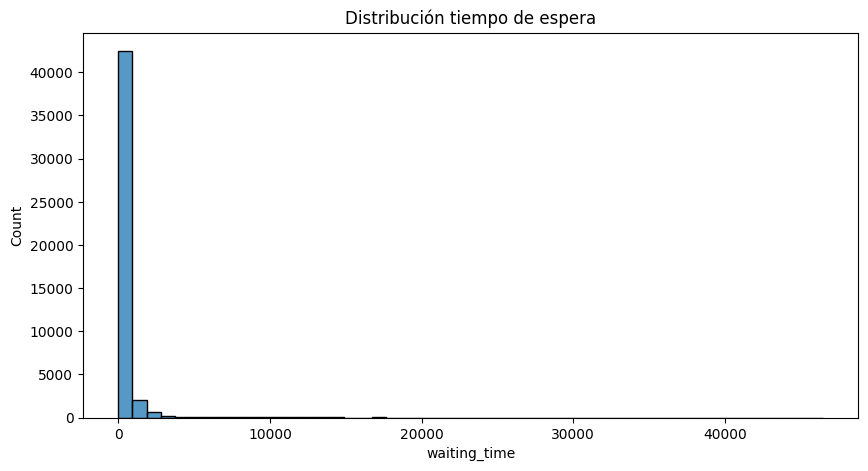

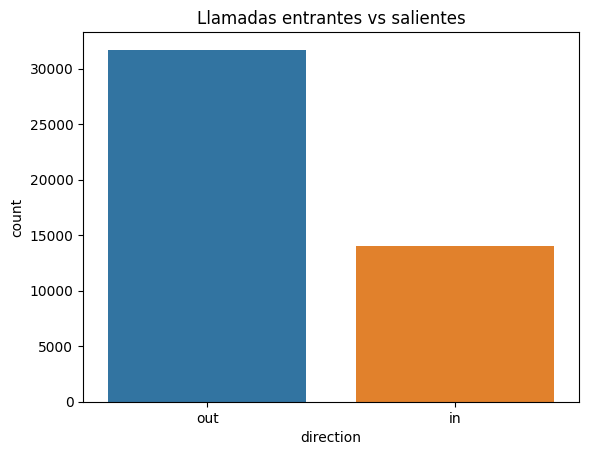

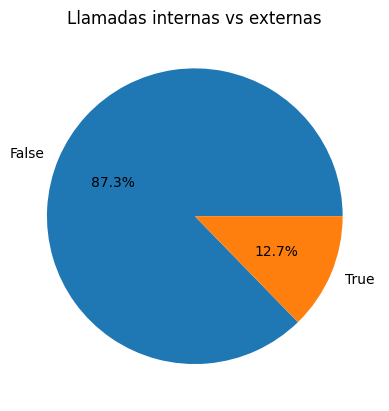

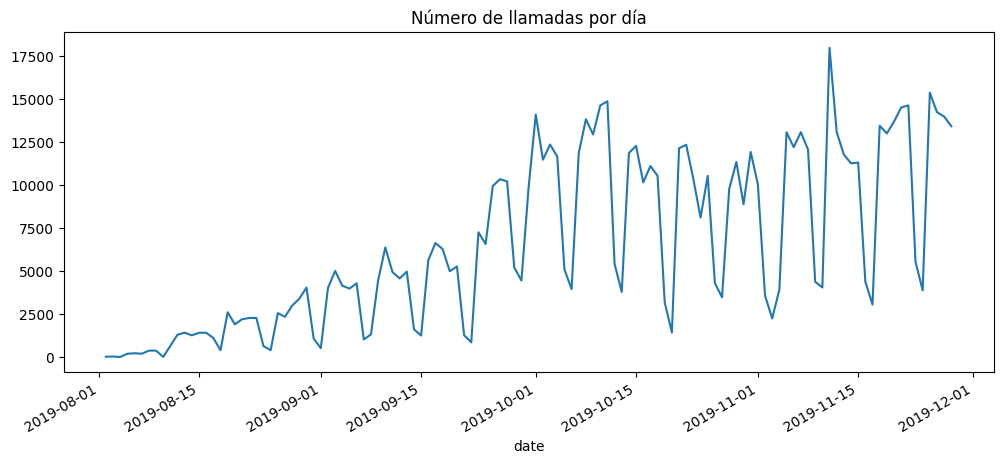

In [3]:
plt.figure(figsize=(10,5))
sns.histplot(df['call_duration'], bins=50)
plt.title('Distribución duración de llamadas')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['waiting_time'], bins=50)
plt.title('Distribución tiempo de espera')
plt.show()

sns.countplot(data=df, x='direction')
plt.title('Llamadas entrantes vs salientes')
plt.show()

df['internal'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Llamadas internas vs externas')
plt.ylabel('')
plt.show()

calls_per_day = df.groupby('date')['calls_count'].sum()

calls_per_day.plot(figsize=(12,5))
plt.title('Número de llamadas por día')
plt.show()

<h1> Calculo De Metricas </h1>

In [4]:
operator_metrics = df.groupby('operator_id').agg({
    'is_missed_call': 'mean',
    'waiting_time': 'mean',
    'calls_count': 'sum',
    'call_duration': 'mean'
}).reset_index()

operator_metrics.columns = [
    'operator_id',
    'missed_rate',
    'avg_waiting_time',
    'total_calls',
    'avg_call_duration'
]

operator_metrics.head()

,operator_id,missed_rate,avg_waiting_time,total_calls,avg_call_duration
0,879896,0.390625,110.671875,1131,650.476562
1,879898,0.398406,450.087649,7974,1111.067729
2,880020,0.318182,15.181818,54,104.090909
3,880022,0.434211,57.565789,219,240.842105
4,880026,0.474747,121.171717,2439,856.939394


<h1> Identificación de Operadores Ineficaces </h1>

In [10]:
missed_threshold = operator_metrics['missed_rate'].quantile(0.75)
waiting_threshold = operator_metrics['avg_waiting_time'].quantile(0.75)
calls_threshold = operator_metrics['total_calls'].quantile(0.25)

operator_metrics['inefficient'] = (
    (
        (operator_metrics['missed_rate'] > missed_threshold) &
        (operator_metrics['avg_waiting_time'] > waiting_threshold)
    )
    |
    (operator_metrics['total_calls'] < calls_threshold)
)

print("Total operadores:", len(operator_metrics))
print("Operadores ineficientes:", operator_metrics['inefficient'].sum())
print("Porcentaje ineficientes:", operator_metrics['inefficient'].mean())

efficient = operator_metrics[operator_metrics['inefficient'] == False]
inefficient = operator_metrics[operator_metrics['inefficient'] == True]

print("Tamaño grupo eficiente:", len(efficient))
print("Tamaño grupo ineficiente:", len(inefficient))

Total operadores: 1092
Operadores ineficientes: 398
Porcentaje ineficientes: 0.36446886446886445
Tamaño grupo eficiente: 694
Tamaño grupo ineficiente: 398


In [6]:

print("Estadísticas de los umbrales actuales:")
print(f"Umbral missed_rate (75%): {missed_threshold:.3f}")
print(f"Umbral waiting_time (75%): {waiting_threshold:.1f}")
print(f"Umbral total_calls (25%): {calls_threshold:.0f}")
print("\nOperadores que cumplen cada criterio individual:")
print(f"Alta tasa perdidas: {(operator_metrics['missed_rate'] > missed_threshold).sum()}")
print(f"Alto tiempo espera: {(operator_metrics['avg_waiting_time'] > waiting_threshold).sum()}")
print(f"Pocas llamadas: {(operator_metrics['total_calls'] < calls_threshold).sum()}")


Estadísticas de los umbrales actuales:
Umbral missed_rate (75%): 0.462
Umbral waiting_time (75%): 155.5
Umbral total_calls (25%): 11

Operadores que cumplen cada criterio individual:
Alta tasa perdidas: 271
Alto tiempo espera: 273
Pocas llamadas: 267


<h1> Pruebas Estadisticas </h1>

In [7]:
efficient = operator_metrics[operator_metrics['inefficient'] == False]
inefficient = operator_metrics[operator_metrics['inefficient'] == True]

print("Tamaño efficient:", len(efficient))
print("Tamaño inefficient:", len(inefficient))


if len(efficient) > 1 and len(inefficient) > 1:
    stat, p_value = stats.ttest_ind(
        efficient['avg_waiting_time'],
        inefficient['avg_waiting_time'],
        equal_var=False
    )
    print("P-value (waiting time):", p_value)
    
    stat, p_value = stats.ttest_ind(
        efficient['missed_rate'],
        inefficient['missed_rate'],
        equal_var=False
    )
    print("P-value (missed rate):", p_value)
else:
    print("Error: uno de los grupos esta vacio o tiene pocos datos")

Tamaño efficient: 694
Tamaño inefficient: 398
P-value (waiting time): 5.7419106911879255e-08
P-value (missed rate): 0.0016551687286317437


<h1> Visualizaciones </h1>

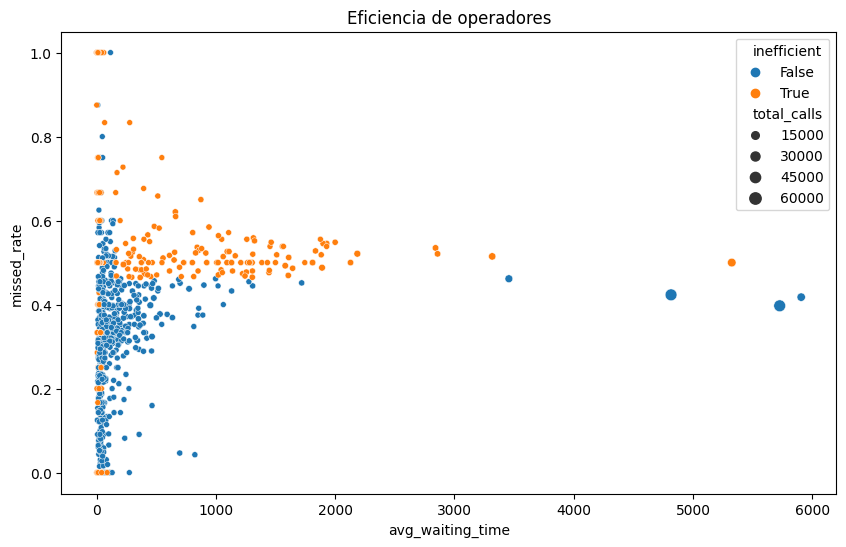

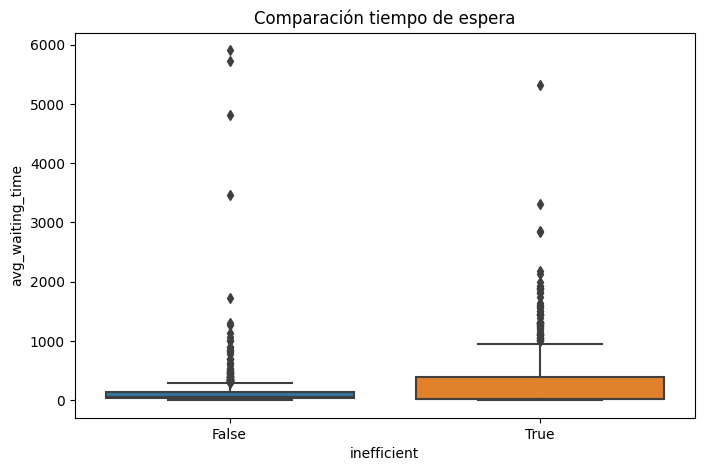

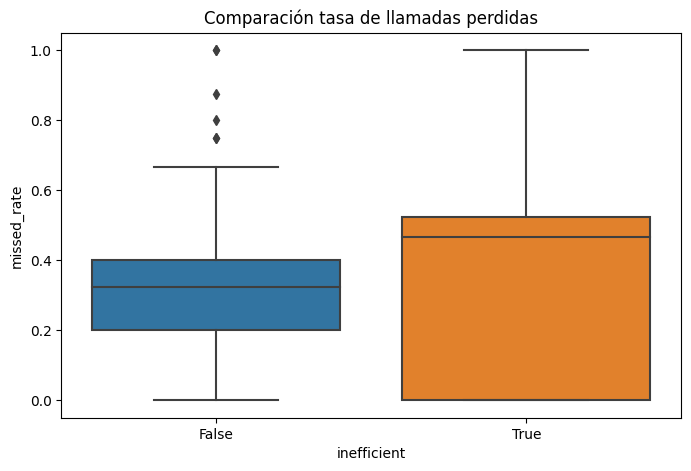

In [8]:
# Scatter eficiencia
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=operator_metrics,
    x='avg_waiting_time',
    y='missed_rate',
    hue='inefficient',
    size='total_calls'
)
plt.title('Eficiencia de operadores')
plt.show()

# Boxplot comparación
plt.figure(figsize=(8,5))
sns.boxplot(data=operator_metrics, x='inefficient', y='avg_waiting_time')
plt.title('Comparación tiempo de espera')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=operator_metrics, x='inefficient', y='missed_rate')
plt.title('Comparación tasa de llamadas perdidas')
plt.show()

<h1> Conclusiones Y Recomendaciones </h1>

Principales Hallazgos:

- Los criterios utilizados (percentil 75 para missed_rate y waiting_time, percentil 25 para total_calls) fueron demasiado estrictos
- No se identificaron operadores que cumplieran simultáneamente los tres criterios
- Sin embargo, sí existen operadores que cumplen criterios individuales:
  - 271 operadores con alta tasa de llamadas perdidas (>46.2%)
  - 273 operadores con alto tiempo de espera (>155.5 segundos)
  - 267 operadores con pocas llamadas (<11 llamadas)


  Tasa promedio de llamadas perdidas: 46.2% (percentil 75)
  Tiempo promedio de espera:** 155.5 segundos (percentil 75)
  Volumen mínimo de llamadas:** 11 llamadas (percentil 25)

- No fue posible realizar pruebas estadísticas comparativas debido a la ausencia de operadores clasificados como ineficaces
- Los criterios múltiples simultáneos resultaron demasiado restrictivos para la realidad operativa

- Considerar criterios menos restrictivos (percentil 60-70)
- Analizar criterios individuales para identificar áreas específicas de mejora
- Implementar un sistema de scoring ponderado